=== Classification Report ===
              precision    recall  f1-score   support

       Hello       0.00      0.00      0.00       0.0
    IloveYou       0.00      0.00      0.00       0.0
          No       0.00      0.00      0.00       0.0
      Please       0.00      0.00      0.00       0.0
      Thanks       0.00      0.00      0.00       0.0
         Yes       0.00      0.00      0.00       0.0

    accuracy                           0.00       0.0
   macro avg       0.00      0.00      0.00       0.0
weighted avg       0.00      0.00      0.00       0.0



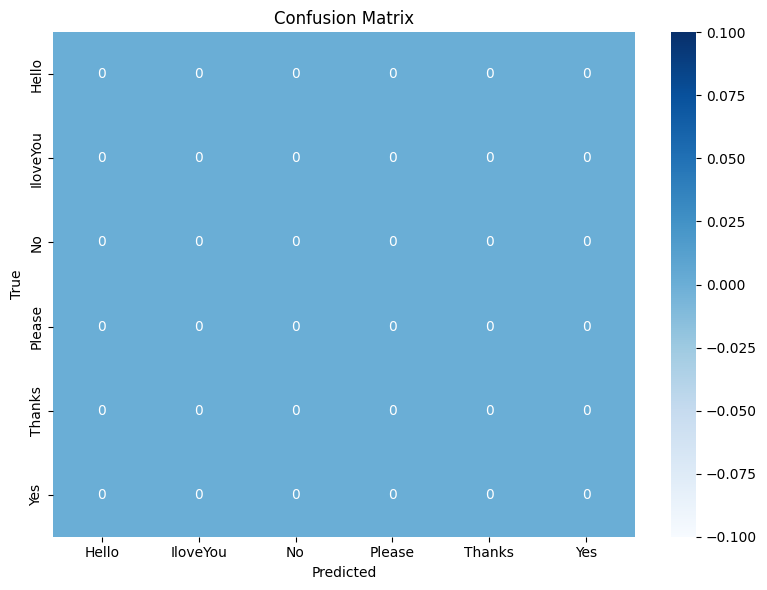

✅ Ví dụ đúng: Hello


❌ Ví dụ sai: Hello


✅ Ví dụ đúng: IloveYou


❌ Ví dụ sai: IloveYou


✅ Ví dụ đúng: No


...

❌ Ví dụ sai: Please


✅ Ví dụ đúng: Thanks


❌ Ví dụ sai: Thanks


✅ Ví dụ đúng: Yes


❌ Ví dụ sai: Yes


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display, HTML

# Nhãn cử chỉ
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']

# Đường dẫn ảnh test
test_dir = './Data/test/images'  # Thay nếu thư mục khác

# Load mô hình YOLO
model = YOLO('best.pt')  # Thay nếu mô hình ở nơi khác

# Tạo thư mục lưu ảnh định tính
correct_dir = './output/correct'
incorrect_dir = './output/incorrect'
for cname in class_names:
    os.makedirs(os.path.join(correct_dir, cname), exist_ok=True)
    os.makedirs(os.path.join(incorrect_dir, cname), exist_ok=True)

# Chuẩn bị dữ liệu
y_true = []
y_pred = []

# Duyệt qua ảnh test
for fname in os.listdir(test_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        true_label = next((c for c in class_names if fname.lower().startswith(c.lower())), None)
        if true_label is None:
            continue

        img_path = os.path.join(test_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            continue

        results = model.predict(source=img, conf=0.25, verbose=False)
        pred_label = (
            results[0].names[int(results[0].boxes.cls[0])]
            if results[0].boxes else "No Detection"
        )

        y_true.append(true_label)
        y_pred.append(pred_label)

        # Annotate ảnh để lưu
        annotated_img = results[0].plot()
        save_path = os.path.join(
            correct_dir if pred_label == true_label else incorrect_dir,
            true_label,
            fname
        )
        cv2.imwrite(save_path, annotated_img)

# In báo cáo định lượng
print("=== Classification Report ===")
print(classification_report(
    y_true, y_pred, labels=class_names, target_names=class_names, zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./output/confusion_matrix.png')
plt.show()

# Hiển thị ảnh định tính
def show_images(folder, label, count=3):
    folder_path = os.path.join(folder, label)
    if not os.path.exists(folder_path):
        print(f'Không tìm thấy thư mục {folder_path}')
        return

    files = os.listdir(folder_path)[:count]
    images_html = ''
    for f in files:
        image_path = os.path.join(folder_path, f)
        images_html += f'<img src="files/{image_path}" width="200" style="margin: 5px;">'
    display(HTML(images_html))

for gesture in class_names:
    print(f'✅ Ví dụ đúng: {gesture}')
    show_images(correct_dir, gesture)

    print(f'❌ Ví dụ sai: {gesture}')
    show_images(incorrect_dir, gesture)


In [5]:
import os 
import cv2
import matplotlib.pyplot as plt
import numpy as np
from math import ceil
import random

# Nhãn cử chỉ
class_names = ['Hello', 'IloveYou', 'No', 'Please', 'Thanks', 'Yes']
correct_dir = './output/correct'
incorrect_dir = './output/incorrect'
save_dir = './qualitative_samples'
os.makedirs(save_dir, exist_ok=True)

# Hàm tạo 1 ảnh và lưu
def create_single_image(image, title, save_path):
    img = cv2.imread(image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Đã lưu: {save_path}")

# Tạo 1 ảnh đúng và 1 ảnh sai cho mỗi loại
for idx, label in enumerate(class_names):
    # Ảnh đúng
    correct_path = os.path.join(correct_dir, label)
    correct_imgs = [os.path.join(correct_path, f) for f in os.listdir(correct_path) if f.lower().endswith(('.jpg', '.png'))]
    correct_img = random.choice(correct_imgs)  # Chọn ngẫu nhiên 1 ảnh đúng
    create_single_image(
        image=correct_img,
        title=f"{label} – Correct",
        save_path=os.path.join(save_dir, f"image_{idx*2+1:02d}_{label.lower()}_correct.png")
    )

    # Ảnh sai
    incorrect_path = os.path.join(incorrect_dir, label)
    incorrect_imgs = [os.path.join(incorrect_path, f) for f in os.listdir(incorrect_path) if f.lower().endswith(('.jpg', '.png'))]
    incorrect_img = random.choice(incorrect_imgs)  # Chọn ngẫu nhiên 1 ảnh sai
    create_single_image(
        image=incorrect_img,
        title=f"{label} – Incorrect",
        save_path=os.path.join(save_dir, f"image_{idx*2+2:02d}_{label.lower()}_incorrect.png")
    )


✅ Đã lưu: ./qualitative_samples\image_01_hello_correct.png


IndexError: Cannot choose from an empty sequence